In [ ]:
import pandas as pd

# upload file (jika di Google Colab)
from google.colab import files
uploaded = files.upload()

# ganti nama file sesuai file kamu
df = pd.read_csv(list(uploaded.keys())[0])

# cek data awal
df.head()


Saving normalisasiBaru (3).csv to normalisasiBaru (3) (4).csv


,at,normalisasi
0,2021-01-01 00:18:10,gem bisapake mod truck new bekaje biar keten
1,2021-01-01 00:19:07,mohon bussid tolong menarik garasi terminaltam...
2,2021-01-01 00:37:58,game sudah bagu min tolong turunin mbak buad m...
3,2021-01-01 03:22:15,abang tolong update tumpang terminal rute tol ...
4,2021-01-01 03:32:00,moga aupdet baru masuk kota medan


In [ ]:
df

,at,normalisasi
0,2021-01-01 00:18:10,gem bisapake mod truck new bekaje biar keten
1,2021-01-01 00:19:07,mohon bussid tolong menarik garasi terminaltam...
2,2021-01-01 00:37:58,game sudah bagu min tolong turunin mbak buad m...
3,2021-01-01 03:22:15,abang tolong update tumpang terminal rute tol ...
4,2021-01-01 03:32:00,moga aupdet baru masuk kota medan
...,...,...
18813,2025-11-27 04:01:31,kasih bintang karena iklan tidak ngotak detik ...
18814,2025-11-27 04:54:37,woi ku tidak pasang mod mobil pls pls bikin
18815,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan
18816,2025-11-27 14:37:59,bis lengkap voyager bis model pilih bis puas b...


In [ ]:
import re

kamus_slang = {
    "bgt": "banget",
    "bgtt": "banget",
    "bngt": "banget",

    "udh": "sudah",
    "sdh": "sudah",
    "udah": "sudah",

    "blm": "belum",
    "belom": "belum",

    "aja": "saja",
    "trs": "terus",
    "trus": "terus",

    "dr": "dari",
    "dg": "dengan",

    "gmn": "bagaimana",
    "gmna": "bagaimana",

    "yg": "yang",
    "dpt": "dapat",

    "krn": "karena",
    "klo": "kalau",
    "kl": "kalau",

    "lg": "lagi",
    "lgi": "lagi",
    "skrg": "sekarang",
    "gk": "tidak", "ga": "tidak", "ngga": "tidak", "nggak": "tidak", "tdk": "tidak",
    "tdak": "tidak", "tak": "tidak",
    "bgt": "banget", "bget": "banget", "sgt": "sangat",
    "pls": "tolong", "plis": "tolong", "pliss": "tolong","plisss": "tolong", "tlng": "tolong", "tolng": "tolong", "plissssssss": "tolong",
    "ok": "oke", "okeh": "oke",
    "pake": "pakai", "pke": "pakai",
    "bgs": "bagus", "bgus": "bagus",
    "bang": "abang", "bg": "bang",
    "gmna": "bagaimana", "gmn": "bagaimana", "god": "baik", "good": "baik", "jossss": "bagus", "josss": "bagus", "josss": "bagus", "sru": "seru", "sry": "seru", "ye": "asyik", "mantep": "mantap",
    "dmn": "di mana",
    "skr": "sekarang", "skrg": "sekarang", "skrng": "sekarang",
    "udh": "sudah", "udah": "sudah", "sdh": "sudah",
    "cpet": "cepat", "cepet": "cepat",
    "bnyk": "banyak", "byk": "banyak",
    "dpt": "dapat", "dapet": "dapat",
    "lg": "lagi", "lgi": "lagi",
    "trs": "terus", "trus": "terus",
    "moga": "semoga",
    "gamenya": "gim",
    "mantul": "mantap", "mantab": "mantap", "bisapake": "bisa pakai",
    "wkwk": "tertawa", "wk": "tertawa",
    "aje": "saja", "aj": "saja", "aja": "saja",
    "min": "admin",
    "gem": "gim", "game": "gim",
    "bisapake": "bisa pakai",
    "truck": "truk", "new": "baru", "bekaje": "bekas", "keten": "keren",
    "terminaltambahin": "terminal tambah", "lagisaya": "lagi saya", "updatenya": "baru", "aupdet": "baru", "apdate": "baru", "apdet": "baru", "updatean": "baru",
    "bagu": "bagus", "turunin": "turun", "buad": "buat", "benerran": "bener", "tolongg": "tolong", "iteus": "terus", "belomabde": "belum baru",
    "matidh": "mati saja", "ajakgimenya": "ajak gim", "spongsornya": "sponsor", "sikitdn sngat": "sedikit banget", "bagustapi": "bagus tapi",
    "next": "lanjut", "mabar": "main bareng", "kediritulung": "kediri tolong", "agungmalangjogjatrustrenggalek": "agung malang jogja terus trenggalek",
    "tambahkan": "tambah", "menambah": "tambah", "perovinsi": "provinsi", "nabrak": "tabrak", "mubil": "mobil", "yoderek": "derek", "benr": "benar",
    "mendonloand": "unduh", "mendonlod": "unduh", "mendonload": "unduh", "download": "unduh", "downloag": "unduh", "donlod": "unduh", "hp": "ponsel", "iini": "ini", "tidah": "tidak", "you tube": "aplikasi youtube",
    "buss": "bus", "mondak mandek": "berhenti", "banyakkkkk": "banyak", "iklannn": "iklan", "skalli": "sekali", "tambhin": "tambah", "tempattempatnya": "tempat tempat",
    "developers": "kembang", "developer": "kembang", "developernya": "kembang", "indonesi": "indonesia", "tementemen": "teman teman",
    "request": "rekomendasi", "anehhgua": "aneh aku", "geronjal geronjal": "tidak rata", "pool": "pul", "sukatp": "suka tapi", "nttkan": "NTT",
    "anjinmmmg": "anjing", "bang": "abang", "mintakk": "minta", "bgjangan": "abang jangan", "bagustapi": "bagus tapi", "tolongbeet": "tolong banget", "nitolong": "ini tolong",
    "kotakendaraandll": "kota kendaraan", "semarangsudah": "semarang sudah", "berlumpurterus": "lumpur terus", "airsekalian": "air sekalian", "ramaikalo": "ramai kalau", "bagusin": "bagus",
    "jugapokok": "juga pokok", "mkasihhh": "terima kasih", "inggin": "ingin", "sihtp": "tapi", "fiturtambah": "fitur tambah", "magelangfitur": "magelang fitur", "black": "hitam", "smart": "pintar", ""
    "kecelakaantambahin": "kecelakaan tambah", " jalanjalan": "jalan jalan", "etsitu": "itu", "sngat": "sangat", "tlong": "tolong", "overall": "seluruh", "selalukomen": "selalu komen", "instal": "unduh", "kecepatan": "cepat",
    "bagu": "bagus", "multiplater": "multi pemain", "mengasih": "kasih", "devmaleo": "kembang maleo", " initingkatkan": "ini tingkat", "real power of indonesia wonderful indonesia": "kekuatan sejati Indonesia yang luar biasa",
    "ngelagann": "lambat", "buriktolong": "jelek tolong", "burikkkkkkkkkkpacemana": "jelek bagaimana", "mic audio": "audio mikrofon", " bagusssss": "bagus", "iklanatau": "iklan atau", "uninstall": "hapus unduh",
    "seruuuuuuu": "seru", "ditambahin": "tambah", "olengvya": "oleng", "tulong": "tolong", "tanbahin": "tambah", "prmintaan": "permintaan", "rutenyasaya": "jalur saya", "nagreg": "narik", "	trimakasih": "terima kasih", "stir": "setir",
    "bedakanterus": "bedakan terus", "trakc": "jalur", "cepatloding": "proses pemuatan dipercepat", "ketutupsoal": "tertutup", "loding": "proses pemuatan", "ketutupgak": "tertutup tidak", "top": "mantap", "ngeleg": "lambat", "mood": "modifikasi",
    "kaliata": "terlihat", "nyatolong": "tolong", "blampungtolong": "lampung tolong", "sumateratrimakasih": "sumatera terima kasih", "ditanbah": "tambah", "jelektapi": "jelek tapi", "narik": "tarik", "tv": "televisi", "donload": "unduh", "ofline": "luring", "best": "baik",
    "bal": "bali", "kotakotanya": "kota kota", "grapfik": "grafik", "bangettapi": "banget tapi", "bagusbisa": "bagus bisa", "kayak": "seperti", "olengbus": "oleng bus", "terhura": "terharu", "manager": "manajer", "force": "paksa", "teloletnya": "bunyi klakson bus unik variatif",
    "mengomongnya": "bicara", "offline online": "luring daring", "bohonggggg": "bohong", "pilittt": "pelit", "knalpotnya": "knalpot", "sabil": "sambil", "berharappp": "berharap", "fc": "klub gemar", "scene": "adegan", "device": "perangkat",
    "tolonggggg": "tolong", "bisaaaa": "bisa", "moddd": "mod", "gituuuu": "begitu", "danfariasi": "dan fariasi", "bangtap": "abang tapi", "tolongharga": "tolong harga", "bangetttttap": "banget tapi", "fps": "jumlah gambar per detik", "rest": "istirahat", "no": "tidak", "memperbaiki": "baik",
    "liveryi": "livery", "gameplay": "gim", "kotaa": "kota", "gameny": "gim", "dev": "kembang", "hancurr": "hancur", "tapiseharusnya": "tapi seharusnya", "jalankaca": "jalan kaca", "screen": "layar", "tibatiba": "tiba tiba", "relog": "masuk ulang", "support": "dukung", "develover": "kembang",
    "seloka": "selokan", "mengalirbus": "mengalir bus", "kotordan": "kotor dan", "penumpangbiar": "penumpang biar", "real": "nyata", "ajadan": "saja", "dibukadan": "buka", "jalandan": "jalan", "semuadan": "semua", "auto": "otomatis", "bocil": "bocah kecil",
    "membanyaki": "banyak", "apk": "aplikasi", "adamod": "ada mod", "lamborgini": "lambor begini", "tulis sannya": "tulisan", "aslih": "asli", "bisah": "bisa", "ajasama": "saja sama", "gebenerin": "tidak perbaiki", "bayak": "banyak", "rating": "nilai",
    "alus": "halus", "alus pisn": "halus banget", "pokona mah": "pokoknya", "effect": "efek", "airasap": "air asap", "tanahjalan": "tanah jalan", "berlobangkonstruksi": "berlubang konstruksi", "ngelayap": "keliling", "shd": "dek super tinggi", "kesel": "kesal", "	gpp": "tidak apa apa",
    "jalankecelakaan": "jalan kecelakaan", "kendaraandan": "kendaraan", "mabarnya": "main bareng", "gm": "gim", "birik": "jelek", "bis": "bus", "mantul": "mantap betul", "tualang": "petualang", "ngambil": "ambil", "body": "badan", "nyeper": "ceper",
    "inidan": "ini dan", "indahjadi": "indah jadi", "beeguna": "berguna", "plisubdate": "tolong perbaiki", "pisssplisss": "tolong", "sumaterabanda": "sumatera banda", "jawatanggerangbandungbekasibandungyogyakarta": "jawa tanggerang bandung bekas bandung yogyakarta",
    "balidenpasar": "bali denpasar", "kalimantanpontianakbanjarmasin": "kalimantan pontianak banjarmasin", "semen tara": "sementara", "kagak": "tidak", "jaladara": "jalan dari", "bengkelkalau": "bengkel kalau", "hilangin": "hilang", "store": "toko",
    "gemnya": "gim", "sukaiini": "suka ini", "anji": "anjing", "ujug ujug": "tiba tiba", "ituterus": "itu terus", "liveryunit": "livery", "jala": "jalan", "didalamtangan": "dalam tangan", "mengganggu": "ganggu", "menghilangkan": "hilang", "memasuki": "masuk", "nambahin": "tambah",
    "nampaktambah": "lihat tambah", "ganenya": "gim", "donlod": "unduh", "updatean": "perbaikan", "sekarangditambah": "sekarang ditambah", "ngalirsmart": "ngalir pintar", "traffickota": "traffic kota", "	mengesalkan": "kesal", "memilih": "pilih", "minus": "kurang", "ngelek": "lambat",
    "speed": "kecepatan", "traffickota": "lalu lintas kota", "trafficstrobo": "lalu lintas stroboskop", "lamonganbatutuban": "lamongan batu tuban", "thanks": "terima kasih", "diperbanya": "perbanyak", "mankin": "makin", "memakai": "pakai", "no": "tidak",
    "dear": "terhormat", "bangmod": "abang mod", "bug": "salah", "btw": "omong omong", "akapgame": "gim", "baguscoba": "bagus coba", "supirnya": "sopir", "tokorumahtoilet": "toko rumah toilet", "rest area": "tempat", "istirahattrmksh": "istirahat terima kasih",
    "sekaliiiiiiiiiiii": "banget", "ngebluurr": "buram", "lagitolong": "lagi tolong", "bank": "abang", "request": "rekomendasi", "tersersh": "terserah", "jateng": "jawa tengah", "prioritasin": "prioritas", "ngebuttan": "ngebut", "nerobos": "terobos", "ngotak": "pikir",
    "tau": "tahu", "jala": "jalan", "bro": "abang", "nyatapi": "tapi", "saranklo": "saran", "mabartrafficnya": "main bareng traffic", "skill": "kemampuan", "jalananga": "jalan", "pengemudinyaitu": "pengemudi yaitu", "burikk bit": "jelek banget", "mencoba": "coba",
    "for": "untuk", "rangin": "reklame", "adalahjalan": "adalah jalan", "barengtolong": "bareng tolong", "please": "tolong", " jawasoale": "jawa soalnya", "agah": "agak", "kekuranggan": "kurang", "nyalip": "salip", "tvrutestikerkap": "tv jalur stiker kap", "toll": "tol", "	setting": "atur",
    "dibukakecepatan": "buka cepat", "gue": "aku", "jawabali": "jawa bali", "pariwisatagame": "pariwisata gim", "kekuranggan": "kurang", "alhampanjang": "panjang", "graphics": "grafik", "okeee": "oke", "kotanyan": "kota", "riques": "rekomendasi",
    "item": "hitam", "ilangin": "hilangin", "adakansemua": "adakan semua", "terimakasi": "terima kasih", "ashik": "asyik", "bosque": "bos", "mantaaaab": "mantap", "omtambah": "om tambah", "ommakasi": "om terima kasih", "palyer": "pemain", "	dibenerin": "benar",
    "tolonk": "tolong", "membuat": "buat", "modya": "mod", "pejal": "pejalan", "kekurangantrotoar": "kurang trotoar", "sepiga": "sepi", "offroadga": "luar jalan tidak", "modkalau": "mod kalau", "micada": "mikrofon ada", "editoke": "edit oke", "full": "penuh",
    "keretalubangbanjirsama": "kereta lubang banjir sama", "nyasudah": "sudah", "bangen": "banget", "kedepannyaupdate" : "kedepannya perbaiki", "naikturun": "naik turun", "kanankiri": "kanan kiri", "adminadminnya": "admin", "seko": "dari", "malangsby tekan saiki": "malang sampai sekarang",
    "gin": "begitu", "bissa": "bisa", "tuju": "tujuan", "kotakotanya": "kota kota", "start": "pertama", "pilisssssssssssssssssss": "tolong", "tambahinbus": "tambah bus", "barusr": "baru sr", "semuagk": "semua tidak", "error": "galat", "segitu": "begitu", "	room": "ruang", "donlot": "unduh",
    "ci anjur": "cianjur", "nice": "bagus", "toolloongg": "tolong", "bangetya": "banget", "cilacapbandungbekasidan": "cilacap bandung bekasi", "seruuuuuuu": "seru", "nariktapi": "tarik tapi", "terminaltambah": "terminal tambah", "ram": "memori akses acak", "modd": "modifikasi",
    "pariwisatauntuk": "pariwisata untuk", "tambahditambah": "tambah", "pilnatiudah": "penalti udah", "komplensoaalnya": "komentar soalnya", "gpp vitur": "tidak apa apa fitur", "tambaah": "tambah", "dkk": "dan teman teman", "mendownload": "unduh",
    "banyaksetelah": "banyak sesudah", "lahuntuk": "untuk", "nglag": "lambat", "bogorr": "bogor", "tasikmalayagarutbandung": "tasikmalaya garut bandung", "kotabaru": "kota baru", "menarik": "tarik", "nadetx": "lanjut", "update": "baru", "skip": "lewat", "npc": "karakter bukan main", "gb": "gigabita",
    "burian": "buru", "sepongsornya": "sponsor", "sikitdn": "sedikit", "dimod": "mod", "dowloa": "unduh", "geme": "gim", "tambain": "tambah", "you tube": "youtube", "mondak mandek": "berhenti terus", "meminta": "minta", "updet": "baru", "ngulang": "ulang",
    "samain": "sama", "tambahain": "tambah", "geronjal geronjal": "rusak", "dimodif": "modifikasi", "games": "gim", "broswer": "pencarian website", "menyesal": "sesal", "kendaraan": "kendara", "pejalan": "jalan", "trafic": "lalu lintas", "menunggu": "tunggu", "	sitinjau": "tinjau", "muas": "puas",
    "updetan": "baru", "dahok": "sudah oke", "rutena": "rute", "jalanjalan": "jaln jalan", "permainannya": "main", "modx": "modifikasi", "initingkatkan": "tingkat", "impi": "inti", "power of indonesia wonderful indonesia": "kuat sejati Indonesia luar biasa", "semoga": "moga",
    "ngelegann": "lambat", "menyarankan": "saran", "mainin": "main", "mic": "mikrofon", "bagusssss": "bagus", "vupan": "cuman", "permintaan": "minta", "dipercept": "cepat", "terlihat": "lihat", "tertutup": "tutup", "pemuatan": "muat", "burik": "jelek", "menyopir": "sopir",
    "jetbus": "jet bus", "lai": "lain", "offline": "luring", "online": "daring", "knlpotnya": "knalpot", "benaran": "benar", "mengahasil": "hasil", "diri": "kediri", "lumajag": "lumajang", "berharap": "harap", "nexs": "lanjut", "jetbud": "jetbus", "kenalpot": "knalpot", "gug gug": "berisik",
    "fois": "suara", "chat": "obrol", "mengetik": "ketik", "makas": "pakai", "bangtapi": "abang tapi", "murahin": "murah", "bangetttttapi": "banget tapi", "hayk": "ayo", "busid": "bussid", "traffic": "lalu lintas", "permintan": "minta", "kabulin": "kabul", "cobah": "coba", "modnya": "mod", "nglayap": "keliling",
    "modnya": "mod", "agengarasi": "agen garasi", "naikin": "naik", "pisn": "banget", "pokona": "pokok", "maleotambahin": "maleo tambah", "berlubang": "lubang", "jakartaburuan": "jakarta buru", "downlod": "unduh", "hayyuk": "ayo", "bussud": "bussid", "terimakasih": "terima kasih", "semoga": "moga",
    "loading": "muat", "kesalahan": "salah", "masang":"pasang", "player": "main", "ngebug": "salah program", "iklannya": "iklan", "busid": "bussid", "file": "dokumen", "pejalan": "jalan", "login": "masuk", "mengadakan": "adakan", "trafik": "lalu lintas", "maps": "peta", "upgrade": "baru", "close": "tutup",
    "lag": "lambat", "ngelag": "lambat", "diupdate": "baru", "pemuatan": "muat", "play": "main", "fix": "tuju", "stuck": "jebak", "team": "tim", "kodename": "kode nama", "acc": "setuju", "dowload": "unduh", "kotakota": "kota kota", "map": "peta", "strobo": "stroboskop", "modif": "modifikasi", "menonton": "tonton"
    }


In [ ]:
def normalize_text(text, kamus):
    text = str(text).lower()

    # hapus angka & simbol
    text = re.sub(r'[^a-z\s]', ' ', text)

    words = text.split()
    normalized_words = []

    for w in words:
        # ganti slang
        if w in kamus:
            normalized_words.append(kamus[w])
        # hapus akhiran "nya"
        elif w.endswith("nya") and w[:-3] in kamus:
            normalized_words.append(kamus[w[:-3]])
        else:
            normalized_words.append(w)

    return " ".join(normalized_words)


In [ ]:
df['normalisasi'] = df['normalisasi'].apply(
    lambda x: normalize_text(x, kamus_slang)
)


In [ ]:
df[['at', 'normalisasi']].head(18745)


,at,normalisasi
0,2021-01-01 00:18:10,gim bisa pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tolong tarik garasi terminal tamb...
2,2021-01-01 00:37:58,gim sudah bagus admin tolong turun mbak buat m...
3,2021-01-01 03:22:15,abang tolong baru tumpang terminal rute tol to...
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan
...,...,...
18740,2025-11-16 08:36:03,banyak iklan anjk
18741,2025-11-16 09:10:21,perangkat gim jalan ingat salah tolong baik ba...
18742,2025-11-16 09:45:07,telolet tidak kedengaran atur telolet
18743,2025-11-16 10:14:03,maleo tolong tambah sterobo tumpuk bus orisina...


In [ ]:
# cek jumlah duplikat di kolom 'normalisasi'
duplicates_count_normalisasi = df['normalisasi'].duplicated().sum()
print(f"Jumlah duplikat di kolom 'normalisasi': {duplicates_count_normalisasi}")

# Cek baris yang merupakan duplikat di kolom 'normalisasi'
duplicate_rows_normalisasi = df[df['normalisasi'].duplicated(keep=False)]
print("\nBaris yang merupakan duplikat di kolom 'normalisasi':")
duplicate_rows_normalisasi[['normalisasi']]

Jumlah duplikat di kolom 'normalisasi': 133

Baris yang merupakan duplikat di kolom 'normalisasi':


,normalisasi
12,gim bagus pasang mod
22,gim seru tambah kota
97,bagus pasang mod
152,mod main bareng
177,gim iklan
...,...
17997,gim buruk iklan
18416,tolong hilang iklan
18488,hilang iklan
18661,unduh mod


In [ ]:
# Hapus duplikat di kolom 'normalisasi'
df.drop_duplicates(subset=['normalisasi'], inplace=True)

# Cek jumlah duplikat di kolom 'normalisasi' setelah penghapusan
duplicates_count_after_normalisasi = df['normalisasi'].duplicated().sum()
print(f"\nJumlah duplikat di kolom 'normalisasi' setelah penghapusan: {duplicates_count_after_normalisasi}")

# Cek baris yang merupakan duplikat setelah penghapusan
duplicate_rows_after_normalisasi = df[df['normalisasi'].duplicated(keep=False)]
print("\nBaris yang merupakan duplikat setelah penghapusan di kolom 'normalisasi':")
duplicate_rows_after_normalisasi[['normalisasi']]
print("Jumlah baris dan kolom:", df.shape)

# Tampilkan 5 baris pertama



Jumlah duplikat di kolom 'normalisasi' setelah penghapusan: 0

Baris yang merupakan duplikat setelah penghapusan di kolom 'normalisasi':
Jumlah baris dan kolom: (18685, 2)


In [ ]:
df

,at,normalisasi
0,2021-01-01 00:18:10,gim bisa pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tolong tarik garasi terminal tamb...
2,2021-01-01 00:37:58,gim sudah bagus admin tolong turun mbak buat m...
3,2021-01-01 03:22:15,abang tolong baru tumpang terminal rute tol to...
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan
...,...,...
18813,2025-11-27 04:01:31,kasih bintang karena iklan tidak pikir detik i...
18814,2025-11-27 04:54:37,woi ku tidak pasang mod mobil tolong tolong bikin
18815,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan
18816,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...


In [ ]:
!pip install Sastrawi


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
all_stopwords = set(factory.get_stop_words())


In [ ]:
stopword_tambahan = {
    "loh", "nya", "di",
    "asalaamualaikum", "aslamualaikum", "assalamualaikum", "tuh", "nge", "mbak", "eh",
    "halo", "mah", "an", "dah", "up", "po", "n", "kali",
    "aji", "alam", "ku", "om", "mas", "lah", "the", "aku", "gua", "amin", "wow", "i", "bu",
    "dll", "kok", "kan", "e", "ah", "woi", "lho", "woy", "kalau",
    "ya", "si", "itu", "yang", "ini", "sih", "lo", "and",
    "kalua", "mah", "aya", "eweh duana", "ter", "ken", "silah", "v", "kak", "gan", "neng",
    "a", "aa", "lai",
    "kenal", "nama", "rafif", "endra", "wardani", "bunda", "lahhhh", "nyadan", "sannya", "nih"
}

In [ ]:
all_stopwords = all_stopwords.union(stopword_tambahan)
print("Total stopword:", len(all_stopwords))


Total stopword: 188


In [ ]:
def remove_stopwords(text, stopwords):
    words = text.split()
    return " ".join([w for w in words if w not in stopwords])


In [ ]:
df['normalisasiBaru'] = df['normalisasi'].apply(
    lambda x: remove_stopwords(x, all_stopwords)
)


In [ ]:
df[['at', 'normalisasiBaru']].head(1000)


,at,normalisasiBaru
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan
...,...,...
997,2021-02-02 11:30:33,tim maleo tambah kota kota bosan tahu kota
998,2021-02-02 11:33:54,bagus kendaraanya jalan rekomendasi banget
999,2021-02-02 11:54:29,baik cusion kota tambah bandung
1000,2021-02-02 11:58:50,gim bagus banget tujuan kota tambah coba rute


In [ ]:
# cek jumlah duplikat di kolom 'normalisasi'
duplicates_count_normalisasi = df['normalisasiBaru'].duplicated().sum()
print(f"Jumlah duplikat di kolom 'normalisasi': {duplicates_count_normalisasi}")

# Cek baris yang merupakan duplikat di kolom 'normalisasi'
duplicate_rows_normalisasi = df[df['normalisasiBaru'].duplicated(keep=False)]
print("\nBaris yang merupakan duplikat di kolom 'normalisasi':")
duplicate_rows_normalisasi[['normalisasiBaru']]

Jumlah duplikat di kolom 'normalisasi': 329

Baris yang merupakan duplikat di kolom 'normalisasi':


,normalisasiBaru
9,iklan
12,gim bagus pasang mod
24,banyak iklan
25,tambah kota bandung
54,rute tambah
...,...
18643,iklan rang
18684,gim bagus iklan kasih bintang
18705,enak iklan
18768,maleo tambah kota bengkulu


In [ ]:
# Hapus duplikat di kolom 'normalisasi'
df.drop_duplicates(subset=['normalisasiBaru'], inplace=True)

# Cek jumlah duplikat di kolom 'normalisasi' setelah penghapusan
duplicates_count_after_normalisasi = df['normalisasiBaru'].duplicated().sum()
print(f"\nJumlah duplikat di kolom 'normalisasi' setelah penghapusan: {duplicates_count_after_normalisasi}")

# Cek baris yang merupakan duplikat setelah penghapusan
duplicate_rows_after_normalisasi = df[df['normalisasiBaru'].duplicated(keep=False)]
print("\nBaris yang merupakan duplikat setelah penghapusan di kolom 'normalisasi':")
duplicate_rows_after_normalisasi[['normalisasiBaru']]
print("Jumlah baris dan kolom:", df.shape)

# Tampilkan 5 baris pertama



Jumlah duplikat di kolom 'normalisasi' setelah penghapusan: 0

Baris yang merupakan duplikat setelah penghapusan di kolom 'normalisasi':
Jumlah baris dan kolom: (18356, 3)


In [ ]:
df

,at,normalisasi,normalisasiBaru
0,2021-01-01 00:18:10,gim bisa pakai mod truk baru bekas biar keren,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tolong tarik garasi terminal tamb...,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim sudah bagus admin tolong turun mbak buat m...,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang tolong baru tumpang terminal rute tol to...,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan,semoga baru baru masuk kota medan
...,...,...,...
18813,2025-11-27 04:01:31,kasih bintang karena iklan tidak pikir detik i...,kasih bintang iklan pikir detik iklan muncul m...
18814,2025-11-27 04:54:37,woi ku tidak pasang mod mobil tolong tolong bikin,pasang mod mobil bikin
18815,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan,serutapi mentok mulu jeda iklan
18816,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...,bus lengkap voyager bus model pilih bus puas b...


In [ ]:
# Hapus baris yang memiliki nilai kosong (NaN, None, atau string kosong) di kolom 'steming_data'
df.dropna(subset=['normalisasiBaru'], inplace=True)
df = df[df['normalisasiBaru'] != '']



In [ ]:
df

,at,normalisasi,normalisasiBaru
0,2021-01-01 00:18:10,gim bisa pakai mod truk baru bekas biar keren,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tolong tarik garasi terminal tamb...,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim sudah bagus admin tolong turun mbak buat m...,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang tolong baru tumpang terminal rute tol to...,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan,semoga baru baru masuk kota medan
...,...,...,...
18813,2025-11-27 04:01:31,kasih bintang karena iklan tidak pikir detik i...,kasih bintang iklan pikir detik iklan muncul m...
18814,2025-11-27 04:54:37,woi ku tidak pasang mod mobil tolong tolong bikin,pasang mod mobil bikin
18815,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan,serutapi mentok mulu jeda iklan
18816,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...,bus lengkap voyager bus model pilih bus puas b...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18356 entries, 0 to 18817
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   at               18356 non-null  object
 1   normalisasi      18356 non-null  object
 2   normalisasiBaru  18356 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


In [ ]:
# cek nilai yang hilang (missing values)
print(df.isnull().sum())

at                 0
normalisasi        0
normalisasiBaru    0
dtype: int64


In [ ]:
# menghapus baris dengan nilai yang hilang
df.dropna(inplace=True)

In [ ]:
df[['at', 'normalisasiBaru']]

,at,normalisasiBaru
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan
...,...,...
18813,2025-11-27 04:01:31,kasih bintang iklan pikir detik iklan muncul m...
18814,2025-11-27 04:54:37,pasang mod mobil bikin
18815,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan
18816,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...


In [ ]:
df[['at', 'normalisasiBaru']].to_csv('Preprocessing.csv', index=False)

In [ ]:
df[['at', 'normalisasiBaru']]

,at,normalisasiBaru
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan
...,...,...
18813,2025-11-27 04:01:31,kasih bintang iklan pikir detik iklan muncul m...
18814,2025-11-27 04:54:37,pasang mod mobil bikin
18815,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan
18816,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...


# Labeling

In [ ]:
import pandas as pd

df = pd.read_csv("/content/Preprocessing.csv")
df.head()

,at,normalisasiBaru
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan


In [ ]:
!git clone https://github.com/fajri91/InSet.git

fatal: destination path 'InSet' already exists and is not an empty directory.


In [ ]:
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

print("Positif (awal):", len(positive_lexicon))
print("Negatif (awal):", len(negative_lexicon))


Positif (awal): 3610
Negatif (awal): 6608


In [ ]:
data = pd.read_csv('/content/Preprocessing.csv')
data.head()

,at,normalisasiBaru
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan


In [ ]:
import pandas as pd
from collections import Counter

all_words = []

for text in df["normalisasiBaru"].dropna():
    all_words.extend(text.split())

word_freq = Counter(all_words)

# 200 kata paling sering muncul
common_words = word_freq.most_common(200)
common_words[:30]

[('gim', 8500),
 ('bagus', 6548),
 ('mod', 5338),
 ('iklan', 5203),
 ('tambah', 5173),
 ('kota', 5105),
 ('main', 5096),
 ('bus', 4396),
 ('baru', 3845),
 ('kasih', 3473),
 ('peta', 2534),
 ('pakai', 2467),
 ('jalan', 2175),
 ('biar', 2033),
 ('banget', 2006),
 ('baik', 1975),
 ('bareng', 1955),
 ('salah', 1904),
 ('maleo', 1876),
 ('mode', 1700),
 ('bussid', 1671),
 ('seru', 1459),
 ('rute', 1441),
 ('pas', 1438),
 ('abang', 1350),
 ('terima', 1317),
 ('pasang', 1280),
 ('bintang', 1238),
 ('suka', 1067),
 ('kendara', 1050)]

In [ ]:
def determine_sentiment(text, threshold=0):
    if not isinstance(text, str):
        return 0, "Netral", [], [], []

    words = text.split()

    positive_words = [w for w in words if w in positive_lexicon]
    negative_words = [w for w in words if w in negative_lexicon]


    score = len(positive_words) - len(negative_words)

    # LOGIKA FINAL
    if score > threshold:
        sentiment = "Positif"
    elif score < -threshold:
        sentiment = "Negatif"
    else:
        sentiment = "Netral"


    return sentiment


In [ ]:
df[["label_lexicon"]] = \
df["normalisasiBaru"].apply(lambda x: pd.Series(determine_sentiment(x)))
df


,at,normalisasiBaru,label_lexicon
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren,Netral
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...,Netral
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...,Positif
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang,Negatif
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan,Negatif
...,...,...,...
18351,2025-11-27 04:01:31,kasih bintang iklan pikir detik iklan muncul m...,Netral
18352,2025-11-27 04:54:37,pasang mod mobil bikin,Positif
18353,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan,Negatif
18354,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...,Positif


In [ ]:
df["label_lexicon"].value_counts()

,count
label_lexicon,
Positif,6810
Negatif,6028
Netral,5518


In [ ]:
df

,at,normalisasiBaru,label_lexicon
0,2021-01-01 00:18:10,gim pakai mod truk baru bekas biar keren,Netral
1,2021-01-01 00:19:07,mohon bussid tarik garasi terminal tambah kota...,Netral
2,2021-01-01 00:37:58,gim bagus admin turun buat mod knalpot serigal...,Positif
3,2021-01-01 03:22:15,abang baru tumpang terminal rute tol abang,Negatif
4,2021-01-01 03:32:00,semoga baru baru masuk kota medan,Negatif
...,...,...,...
18351,2025-11-27 04:01:31,kasih bintang iklan pikir detik iklan muncul m...,Netral
18352,2025-11-27 04:54:37,pasang mod mobil bikin,Positif
18353,2025-11-27 07:44:22,serutapi mentok mulu jeda iklan,Negatif
18354,2025-11-27 14:37:59,bus lengkap voyager bus model pilih bus puas b...,Positif


/tmp/ipython-input-1381787786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='pastel')


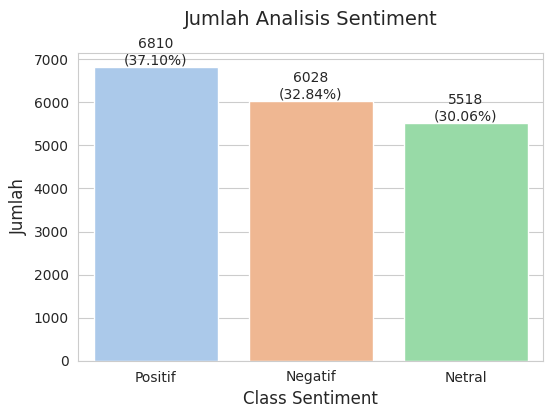

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Access the correct column 'sentimen' instead of 'Sentiment'
sentiment_counts = df['label_lexicon'].value_counts()

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='pastel')
plt.title('Jumlah Analisis Sentiment', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

total = len(df['label_lexicon']) # Use 'sentimen' for total count

for i, count in enumerate(sentiment_counts.values):
  percentage = f'{100 * count / total:.2f}%'
  ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom' )

plt.show()

In [ ]:
X = df['normalisasiBaru']
y = df['label_lexicon']


# TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(ngram_range=(1,2))

In [ ]:
X_tfidf = tfidf.fit_transform(df['normalisasiBaru'])
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 370452 stored elements and shape (18356, 105007)>

In [ ]:
# Cek hasil
print("Jumlah fitur TF-IDF:", len(tfidf.get_feature_names_out()))

Jumlah fitur TF-IDF: 105007


In [ ]:
from sklearn.model_selection import train_test_split

X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(
    X_tfidf, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

print("Split 90:10")
print("Train:", X_train_10.shape)
print("Test :", X_test_10.shape)


Split 90:10
Train: (16520, 105007)
Test : (1836, 105007)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_20, X_test_20, y_train_20, y_test_20 = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Split 80:20")
print("Train:", X_train_20.shape)
print("Test :", X_test_20.shape)


Split 80:20
Train: (14684, 105007)
Test : (3672, 105007)


In [ ]:
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X_tfidf, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Split 30:70")
print("Train:", X_train_30.shape)
print("Test :", X_test_30.shape)


Split 30:70
Train: (12849, 105007)
Test : (5507, 105007)


In [ ]:
import pandas as pd

# Membuat ringkasan hasil split
data_split = {
    "Split Data": ["90:10", "80:20", "70:30"],
    "Jumlah Data Train": [
        X_train_10.shape[0],
        X_train_20.shape[0],
        X_train_30.shape[0]
    ],
    "Jumlah Data Test": [
        X_test_10.shape[0],
        X_test_20.shape[0],
        X_test_30.shape[0]
    ],
    "Jumlah Fitur (TF-IDF)": [
        X_train_10.shape[1],
        X_train_20.shape[1],
        X_train_30.shape[1]
    ]
}

# Konversi ke DataFrame
df_split = pd.DataFrame(data_split)

# Tampilkan tabel
df_split


,Split Data,Jumlah Data Train,Jumlah Data Test,Jumlah Fitur (TF-IDF)
0,90:10,16520,1836,105007
1,80:20,14684,3672,105007
2,70:30,12849,5507,105007


# Logistic Regression

In [ ]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model Logistic Regression
model = LogisticRegression(max_iter=1000)

# TRAIN pakai TF-IDF
model.fit(X_train_10, y_train_10)

# Prediksi


y_pred_re_10 = model.predict(X_test_10)

# Evaluasi
accuracy = accuracy_score(y_test_10, y_pred_re_10)
cm_lr_10 = confusion_matrix(y_test_10, y_pred_re_10)

print("Akurasi:", accuracy)
print("Confusion Matrix:\n", cm_lr_10)
print("\nClassification Report:\n", classification_report(y_test_10, y_pred_re_10))


Akurasi: 0.8110021786492375
Confusion Matrix:
 [[506  66  31]
 [ 96 381  75]
 [ 20  59 602]]

Classification Report:
               precision    recall  f1-score   support

     Negatif       0.81      0.84      0.83       603
      Netral       0.75      0.69      0.72       552
     Positif       0.85      0.88      0.87       681

    accuracy                           0.81      1836
   macro avg       0.81      0.80      0.80      1836
weighted avg       0.81      0.81      0.81      1836



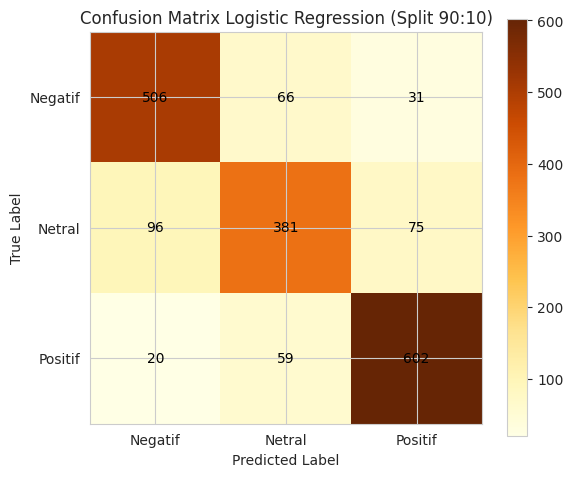

In [ ]:
# Hitung confusion matrix
cm_lr_10 = confusion_matrix(y_test_10, y_pred_re_10)

# Label kelas
labels = ['Negatif', 'Netral', 'Positif']

# Visualisasi
plt.figure(figsize=(6, 5))
plt.imshow(cm_lr_10, cmap='YlOrBr')  # 🌕 WARNA KUNING
plt.title("Confusion Matrix Logistic Regression (Split 90:10)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# Tampilkan nilai di setiap sel
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm_lr_10[i, j],
                 ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# Model Logistic Regression
model_20 = LogisticRegression(max_iter=1000)

# TRAIN pakai TF-IDF (80:20)
model_20.fit(X_train_20, y_train_20)

# Prediksi
y_pred_re_20 = model_20.predict(X_test_20)

# Evaluasi
accuracy_20 = accuracy_score(y_test_20, y_pred_re_20)
cm_lr_20 = confusion_matrix(y_test_20, y_pred_re_20)

print("Akurasi (80:20):", accuracy_20)
print("Confusion Matrix (80:20):\n", cm_lr_20)
print("\nClassification Report (80:20):\n",
      classification_report(y_test_20, y_pred_re_20))


Akurasi (80:20): 0.7992919389978214
Confusion Matrix (80:20):
 [[ 990  144   72]
 [ 174  752  178]
 [  34  135 1193]]

Classification Report (80:20):
               precision    recall  f1-score   support

     Negatif       0.83      0.82      0.82      1206
      Netral       0.73      0.68      0.70      1104
     Positif       0.83      0.88      0.85      1362

    accuracy                           0.80      3672
   macro avg       0.79      0.79      0.79      3672
weighted avg       0.80      0.80      0.80      3672



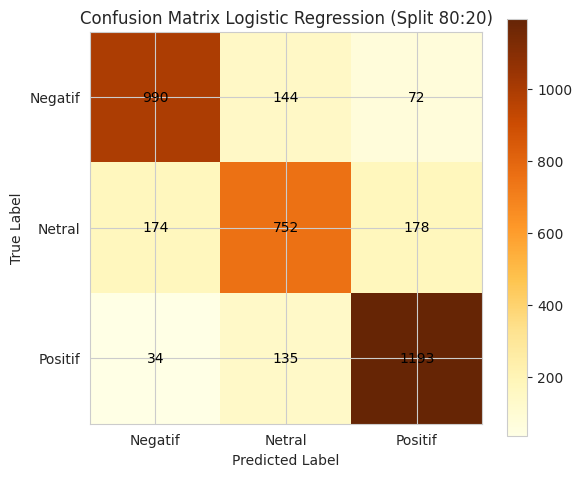

In [ ]:
# Confusion matrix (80:20)
cm_lr_20 = confusion_matrix(y_test_20, y_pred_re_20)

# Label kelas
labels = ['Negatif', 'Netral', 'Positif']

# Visualisasi
plt.figure(figsize=(6, 5))
plt.imshow(cm_lr_20, cmap='YlOrBr')  # 🌕 WARNA SAMA DENGAN 90:10
plt.title("Confusion Matrix Logistic Regression (Split 80:20)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# Tampilkan nilai di setiap sel
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm_lr_20[i, j],
                 ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# Model Logistic Regression
model_30 = LogisticRegression(max_iter=1000)

# TRAIN pakai TF-IDF (70:30)
model_30.fit(X_train_30, y_train_30)

# Prediksi
y_pred_re_30 = model_30.predict(X_test_30)

# Evaluasi
accuracy_30 = accuracy_score(y_test_30, y_pred_re_30)
cm_lr_30 = confusion_matrix(y_test_30, y_pred_re_30)

print("Akurasi (70:30):", accuracy_30)
print("Confusion Matrix (70:30):\n", cm_lr_30)
print("\nClassification Report (70:30):\n",
      classification_report(y_test_30, y_pred_re_30))


Akurasi (70:30): 0.7900853459233702
Confusion Matrix (70:30):
 [[1490  218  101]
 [ 276 1084  295]
 [  61  205 1777]]

Classification Report (70:30):
               precision    recall  f1-score   support

     Negatif       0.82      0.82      0.82      1809
      Netral       0.72      0.65      0.69      1655
     Positif       0.82      0.87      0.84      2043

    accuracy                           0.79      5507
   macro avg       0.78      0.78      0.78      5507
weighted avg       0.79      0.79      0.79      5507



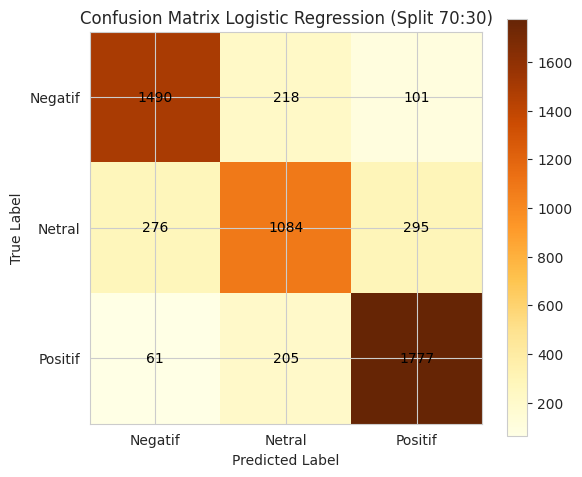

In [ ]:
# Confusion matrix (70:30)
cm_lr_30 = confusion_matrix(y_test_30, y_pred_re_30)

# Label kelas
labels = ['Negatif', 'Netral', 'Positif']

# Visualisasi
plt.figure(figsize=(6, 5))
plt.imshow(cm_lr_30, cmap='YlOrBr')  # 🌕 WARNA KUNING SAMA
plt.title("Confusion Matrix Logistic Regression (Split 70:30)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)

# Tampilkan nilai di setiap sel
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm_lr_30[i, j],
                 ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()


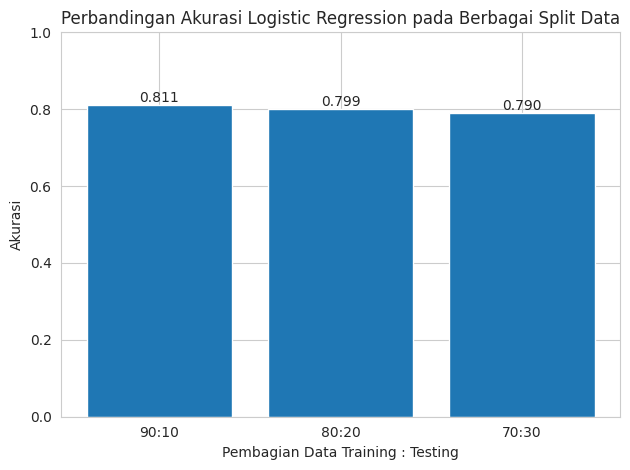

In [ ]:
import matplotlib.pyplot as plt

# Label split data
splits = ['90:10', '80:20', '70:30']

# Akurasi Logistic Regression
accuracies = [accuracy, accuracy_20, accuracy_30]

plt.figure()
bars = plt.bar(splits, accuracies)

plt.xlabel('Pembagian Data Training : Testing')
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Logistic Regression pada Berbagai Split Data')
plt.ylim(0, 1)

# Menampilkan nilai akurasi di atas setiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',  # 3 angka di belakang koma
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# SVM

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

90:10 (Training Testing)

In [ ]:
# Train SVM
svm_model = LinearSVC()
svm_model.fit(X_train_10, y_train_10)

# Prediksi DATA TEST
y_pred_10 = svm_model.predict(X_test_10)

acc_svm_10 = accuracy_score(y_test_10, y_pred_10)

# Evaluasi
print("Akurasi 90:10 :", acc_svm_10)
print(classification_report(y_test_10, y_pred_10))

Akurasi 90:10 : 0.8431372549019608
              precision    recall  f1-score   support

     Negatif       0.83      0.88      0.85       603
      Netral       0.81      0.69      0.75       552
     Positif       0.88      0.93      0.90       681

    accuracy                           0.84      1836
   macro avg       0.84      0.84      0.83      1836
weighted avg       0.84      0.84      0.84      1836



[[529  54  20]
 [100 383  69]
 [ 10  35 636]]


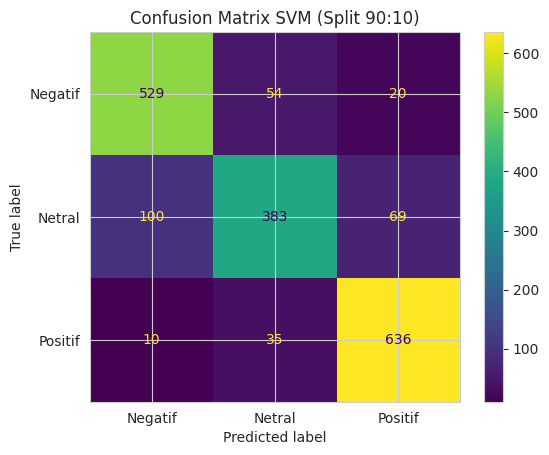

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_svm_10 = confusion_matrix(y_test_10, y_pred_10)
print(cm_svm_10)

labels = ['Negatif', 'Netral', 'Positif']

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_10, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix SVM (Split 90:10)")
plt.show()


80:20 (Training Testing)

In [ ]:
# Train SVM
svm_model = LinearSVC()
svm_model.fit(X_train_20, y_train_20)

# Prediksi DATA TEST
y_pred_20 = svm_model.predict(X_test_20)

acc_svm_20 = accuracy_score(y_test_20, y_pred_20)

# Evaluasi
print("Akurasi 80:20 :", acc_svm_20)
print(classification_report(y_test_20, y_pred_20))

Akurasi 80:20 : 0.8202614379084967
              precision    recall  f1-score   support

     Negatif       0.83      0.86      0.85      1206
      Netral       0.76      0.67      0.71      1104
     Positif       0.85      0.91      0.88      1362

    accuracy                           0.82      3672
   macro avg       0.81      0.81      0.81      3672
weighted avg       0.82      0.82      0.82      3672



[[1041  118   47]
 [ 191  737  176]
 [  16  112 1234]]


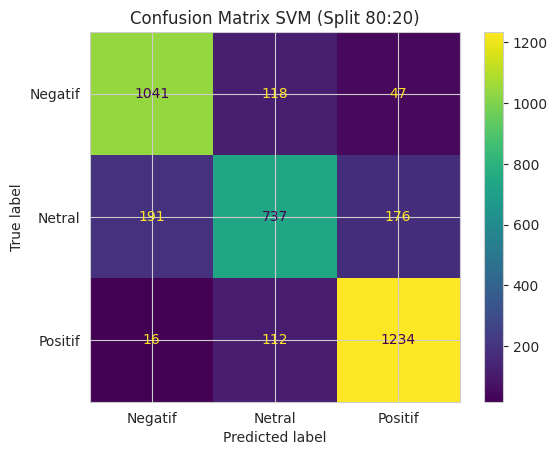

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_svm_20 = confusion_matrix(y_test_20, y_pred_20)
print(cm_svm_20)

labels = ['Negatif', 'Netral', 'Positif']

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_20, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix SVM (Split 80:20)")
plt.show()


70:30 (Training Testing)

In [ ]:
# Train SVM
svm_model = LinearSVC()
svm_model.fit(X_train_30, y_train_30)

# Prediksi DATA TEST
y_pred_30 = svm_model.predict(X_test_30)

acc_svm_30 = accuracy_score(y_test_30, y_pred_30)

# Evaluasi
print("Akurasi 70:30: ", acc_svm_30)
print(classification_report(y_test_30, y_pred_30))

Akurasi 70:30:  0.8095151625204285
              precision    recall  f1-score   support

     Negatif       0.83      0.86      0.84      1809
      Netral       0.75      0.65      0.69      1655
     Positif       0.83      0.90      0.86      2043

    accuracy                           0.81      5507
   macro avg       0.80      0.80      0.80      5507
weighted avg       0.81      0.81      0.81      5507



[[1553  186   70]
 [ 289 1071  295]
 [  30  179 1834]]


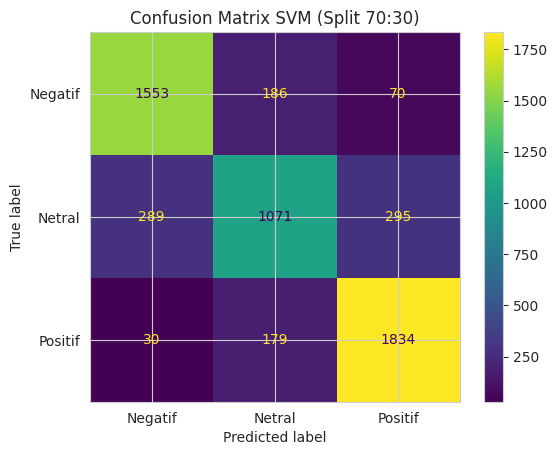

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_svm_30 = confusion_matrix(y_test_30, y_pred_30)
print(cm_svm_30)

labels = ['Negatif', 'Netral', 'Positif']

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_30, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix SVM (Split 70:30)")
plt.show()


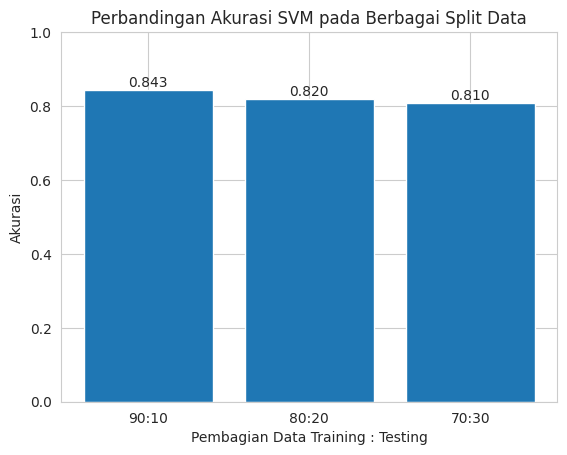

In [ ]:
import matplotlib.pyplot as plt

splits = ['90:10', '80:20', '70:30']
accuracies = [acc_svm_10, acc_svm_20, acc_svm_30]

plt.figure()
bars = plt.bar(splits, accuracies)

plt.xlabel('Pembagian Data Training : Testing')
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi SVM pada Berbagai Split Data')
plt.ylim(0, 1)

# Menampilkan nilai akurasi di atas setiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',   # 3 angka di belakang koma
        ha='center',
        va='bottom'
    )

plt.show()


# Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
nb_10 = MultinomialNB()
nb_10.fit(X_train_10, y_train_10)

y_pred_nb_10 = nb_10.predict(X_test_10)

acc_nb_10 = accuracy_score(y_test_10, y_pred_nb_10)

cm_nb_10 = confusion_matrix(y_test_10, y_pred_nb_10, labels=nb_10.classes_)

print("Akurasi NB 90:10 =", acc_nb_10)
print("Confusion Matrix (90:10):\n", cm_nb_10)
print(classification_report(y_test_10, y_pred_nb_10))


Akurasi NB 90:10 = 0.6595860566448801
Confusion Matrix (90:10):
 [[438  26 139]
 [119 124 309]
 [ 24   8 649]]
              precision    recall  f1-score   support

     Negatif       0.75      0.73      0.74       603
      Netral       0.78      0.22      0.35       552
     Positif       0.59      0.95      0.73       681

    accuracy                           0.66      1836
   macro avg       0.71      0.63      0.61      1836
weighted avg       0.70      0.66      0.62      1836



[[438  26 139]
 [119 124 309]
 [ 24   8 649]]


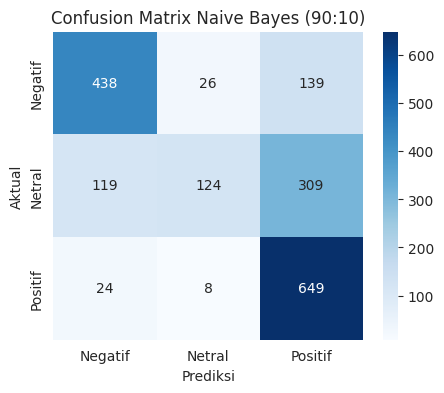

In [ ]:
cm_nb_10 = confusion_matrix(y_test_10, y_pred_nb_10, labels=nb_10.classes_)
print(cm_nb_10)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb_10, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_10.classes_,
            yticklabels=nb_10.classes_)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Naive Bayes (90:10)")
plt.show()

In [ ]:
nb_20 = MultinomialNB()
nb_20.fit(X_train_20, y_train_20)

y_pred_nb_20 = nb_20.predict(X_test_20)

acc_nb_20 = accuracy_score(y_test_20, y_pred_nb_20)

print("Akurasi NB 80:20 =", acc_nb_20)
print(classification_report(y_test_20, y_pred_nb_20))

Akurasi NB 80:20 = 0.644880174291939
              precision    recall  f1-score   support

     Negatif       0.74      0.71      0.72      1206
      Netral       0.77      0.20      0.32      1104
     Positif       0.58      0.95      0.72      1362

    accuracy                           0.64      3672
   macro avg       0.70      0.62      0.59      3672
weighted avg       0.69      0.64      0.60      3672



[[ 854   50  302]
 [ 244  226  634]
 [  55   19 1288]]


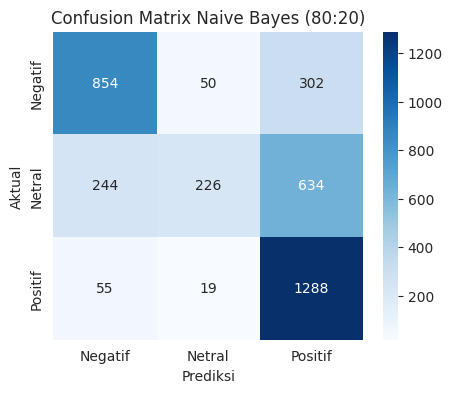

In [ ]:
cm_nb_20 = confusion_matrix(y_test_20, y_pred_nb_20, labels=nb_20.classes_)
print(cm_nb_20)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb_20, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_20.classes_,
            yticklabels=nb_20.classes_)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Naive Bayes (80:20)")
plt.show()

In [ ]:
nb_30 = MultinomialNB()
nb_30.fit(X_train_30, y_train_30)

y_pred_nb_30 = nb_30.predict(X_test_30)

acc_nb_30 = accuracy_score(y_test_30, y_pred_nb_30)

print("Akurasi NB 70:30 =", acc_nb_30)
print(classification_report(y_test_30, y_pred_nb_30))

Akurasi NB 70:30 = 0.6444525149809334
              precision    recall  f1-score   support

     Negatif       0.75      0.71      0.73      1809
      Netral       0.77      0.20      0.31      1655
     Positif       0.57      0.95      0.71      2043

    accuracy                           0.64      5507
   macro avg       0.70      0.62      0.59      5507
weighted avg       0.69      0.64      0.60      5507



[[1290   67  452]
 [ 345  325  985]
 [  81   28 1934]]


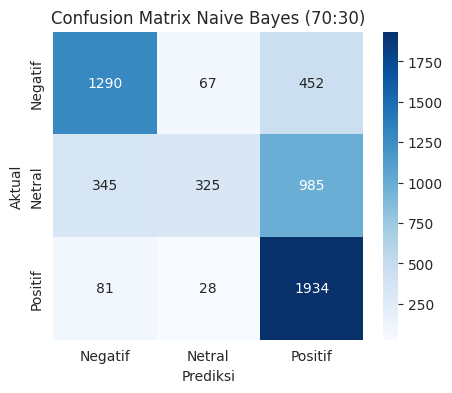

In [ ]:
cm_nb_30 = confusion_matrix(y_test_30, y_pred_nb_30, labels=nb_30.classes_)
print(cm_nb_30)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb_30, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_30.classes_,
            yticklabels=nb_30.classes_)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Naive Bayes (70:30)")
plt.show()

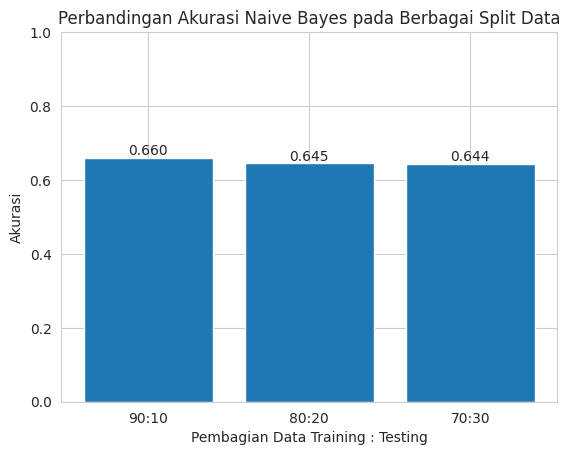

In [ ]:
import matplotlib.pyplot as plt

splits = ['90:10', '80:20', '70:30']
accuracies = [acc_nb_10, acc_nb_20, acc_nb_30]

plt.figure()
bars = plt.bar(splits, accuracies)

plt.xlabel('Pembagian Data Training : Testing')
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Naive Bayes pada Berbagai Split Data')
plt.ylim(0, 1)

# Menampilkan nilai akurasi di atas setiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}',   # 3 angka di belakang koma
        ha='center',
        va='bottom'
    )

plt.show()


In [ ]:
import pandas as pd

hasil_perbandingan = pd.DataFrame({
    "Split Data": ["90:10", "80:20", "70:30"],
    "Akurasi Naive Bayes": [acc_nb_10, acc_nb_20, acc_nb_30],
    "Akurasi SVM": [acc_svm_10, acc_svm_20, acc_svm_30]
})

hasil_perbandingan


,Split Data,Akurasi Naive Bayes,Akurasi SVM
0,90:10,0.659586,0.843137
1,80:20,0.644880,0.820261
2,70:30,0.644453,0.809515


In [ ]:
import pandas as pd
import numpy as np

# =========================
# Ambil dari variabel CM
# =========================
confusion_data = {
    ('90:10', 'Naive Bayes'): cm_nb_10,
    ('90:10', 'SVM'): cm_svm_10,
    ('90:10', 'Logistic Regression'): cm_lr_10,

    ('80:20', 'Naive Bayes'): cm_nb_20,
    ('80:20', 'SVM'): cm_svm_20,
    ('80:20', 'Logistic Regression'): cm_lr_20,

    ('70:30', 'Naive Bayes'): cm_nb_30,
    ('70:30', 'SVM'): cm_svm_30,
    ('70:30', 'Logistic Regression'): cm_lr_30,
}

rows = []

for (split, model), cm in confusion_data.items():
    TP_total = np.trace(cm)
    FP_total = sum(cm[:, i].sum() - cm[i, i] for i in range(cm.shape[0]))
    FN_total = sum(cm[i, :].sum() - cm[i, i] for i in range(cm.shape[0]))
    TN_total = cm.sum() * cm.shape[0] - (TP_total + FP_total + FN_total)

    # Fokus kelas Netral (index = 1)
    true_netral = cm[1, 1]
    false_netral = cm[1, :].sum() - cm[1, 1]

    rows.append([
        split, model,
        TP_total, FP_total, FN_total, TN_total,
        true_netral, false_netral
    ])

df_summary = pd.DataFrame(
    rows,
    columns=[
        'Split Data', 'Model',
        'TP Total', 'FP Total', 'FN Total', 'TN Total',
        'True Netral', 'False Netral'
    ]
)

df_summary


,Split Data,Model,TP Total,FP Total,FN Total,TN Total,True Netral,False Netral
0,90:10,Naive Bayes,1211,625,625,3047,124,428
1,90:10,SVM,1548,288,288,3384,383,169
2,90:10,Logistic Regression,1489,347,347,3325,381,171
3,80:20,Naive Bayes,2368,1304,1304,6040,226,878
4,80:20,SVM,3012,660,660,6684,737,367
5,80:20,Logistic Regression,2935,737,737,6607,752,352
6,70:30,Naive Bayes,3549,1958,1958,9056,325,1330
7,70:30,SVM,4458,1049,1049,9965,1071,584
8,70:30,Logistic Regression,4351,1156,1156,9858,1084,571


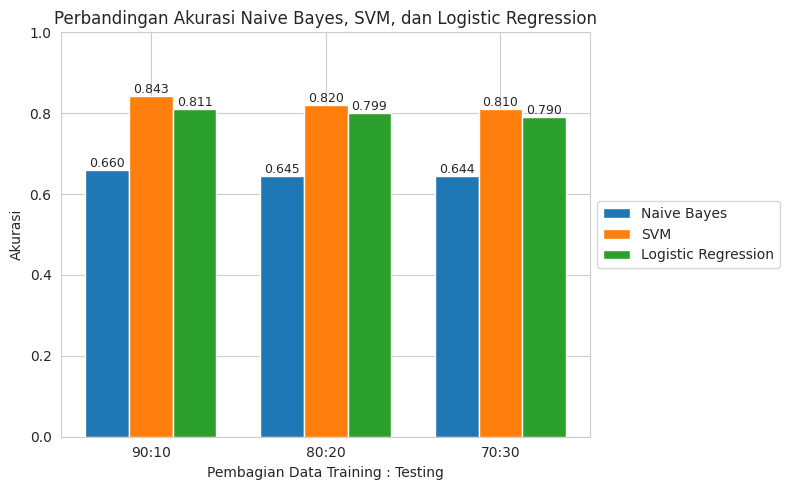

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
splits = ["90:10", "80:20", "70:30"]

acc_nb = [acc_nb_10, acc_nb_20, acc_nb_30]
acc_svm = [acc_svm_10, acc_svm_20, acc_svm_30]
acc_lr = [accuracy, accuracy_20, accuracy_30]

x = np.arange(len(splits))
width = 0.25

plt.figure(figsize=(8, 5))

bars_nb = plt.bar(x - width, acc_nb, width, label='Naive Bayes')
bars_svm = plt.bar(x, acc_svm, width, label='SVM')
bars_lr = plt.bar(x + width, acc_lr, width, label='Logistic Regression')

plt.xlabel('Pembagian Data Training : Testing')
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Naive Bayes, SVM, dan Logistic Regression')
plt.xticks(x, splits)
plt.ylim(0, 1)

# Legend dipindah ke luar
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Angka di atas bar
for bars in [bars_nb, bars_svm, bars_lr]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()


In [ ]:
df[['at', 'normalisasiBaru', 'label_lexicon']].to_csv('HasilAnalisisSentimen.csv',index=False)

# WordCloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


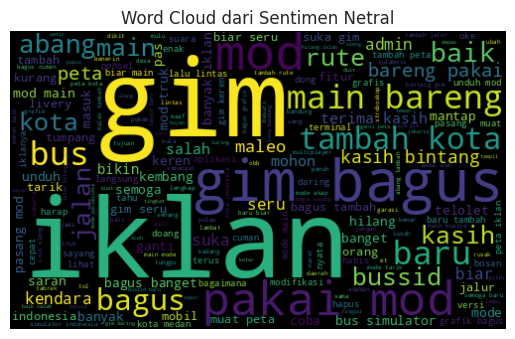

In [ ]:
# WordCloud dari sentimen netral

df_netral = df[df['label_lexicon'] == 'Netral']
all_words_netral = ' '.join([i for i in df_netral['normalisasiBaru']])
wordcloud_netral = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_netral)

plt.imshow(wordcloud_netral, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud dari Sentimen Netral')
plt.show()

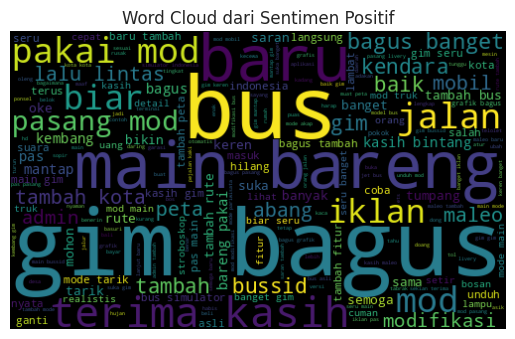

In [ ]:
# WordCloud dari sentimen positif
df_positif = df[df['label_lexicon'] == 'Positif']
all_words_positif = ' '.join([twts for twts in df_positif['normalisasiBaru']])
wordcloud_positif = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_positif)

plt.imshow(wordcloud_positif, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud dari Sentimen Positif')
plt.show()

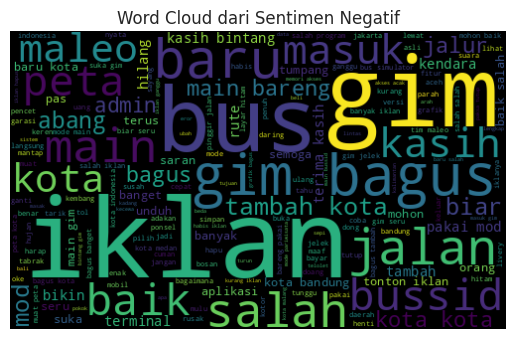

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

# WordCloud dari sentimen negatif
df_negatif = df[df['label_lexicon'] == 'Negatif']
all_words_negatif = ' '.join([twts for twts in df_negatif['normalisasiBaru']])
wordcloud_negatif = WordCloud(width=500, height=300, random_state=21, max_font_size=110).generate(all_words_negatif)

plt.imshow(wordcloud_negatif, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud dari Sentimen Negatif')
plt.show()


In [ ]:
X = df['normalisasiBaru']
y = df['label_lexicon']


# EDA

<Figure size 640x480 with 0 Axes>

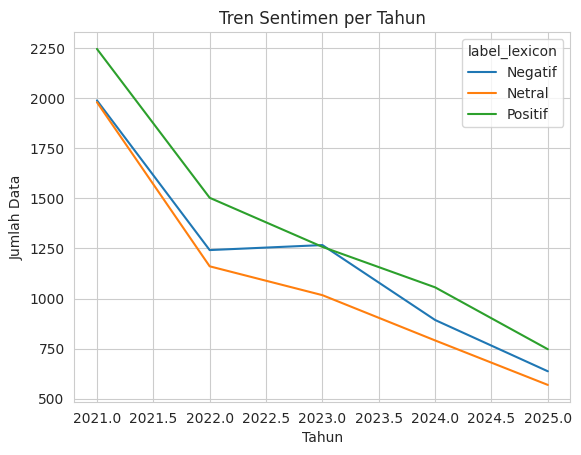

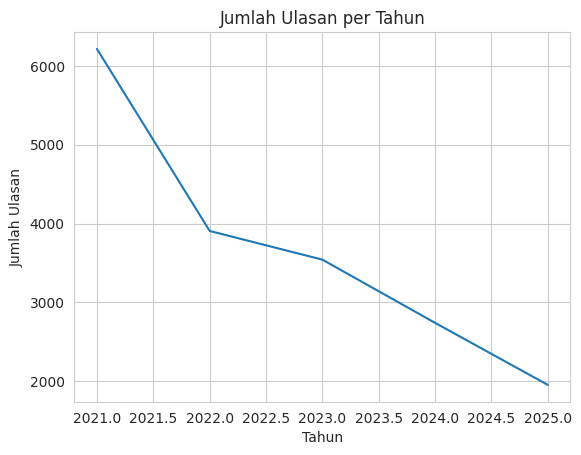

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/HasilAnalisisSentimen.csv")

# Convert date column
df['at'] = pd.to_datetime(df['at'])

# Add year and month columns
df['year'] = df['at'].dt.year
df['month'] = df['at'].dt.month

# 2. Grafik sentimen per tahun
yearly_sentiment = df.groupby(['year', 'label_lexicon']).size().unstack(fill_value=0)
plt.figure()
yearly_sentiment.plot()
plt.title("Tren Sentimen per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Data")
plt.show()

# 3. Grafik jumlah data per tahun
yearly_total = df['year'].value_counts().sort_index()
plt.figure()
yearly_total.plot(kind='line')
plt.title("Jumlah Ulasan per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Ulasan")
plt.show()


/tmp/ipython-input-2353485939.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2021['month'] = df_2021['at'].dt.month


<Figure size 640x480 with 0 Axes>

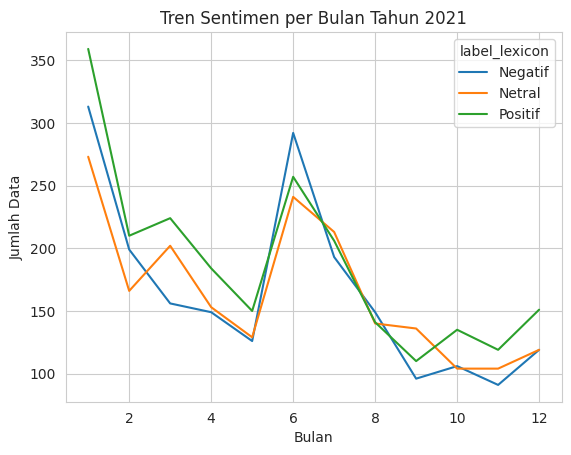

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Filter tahun tertentu
df_2021 = df[df['at'].dt.year == 2021]

df_2021['month'] = df_2021['at'].dt.month

monthly_2021 = df_2021.groupby(['month', 'label_lexicon']).size().unstack(fill_value=0)

plt.figure()
monthly_2021.plot()
plt.title("Tren Sentimen per Bulan Tahun 2021")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.show()


/tmp/ipython-input-3155608328.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2022['month'] = df_2022['at'].dt.month


<Figure size 640x480 with 0 Axes>

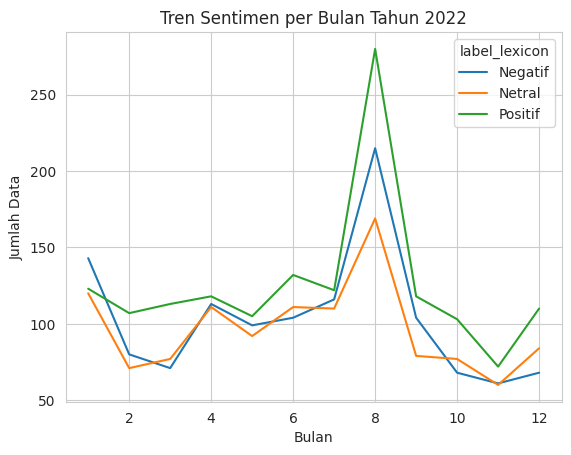

In [ ]:
# Filter tahun tertentu
df_2022 = df[df['at'].dt.year == 2022]

df_2022['month'] = df_2022['at'].dt.month

monthly_2022 = df_2022.groupby(['month', 'label_lexicon']).size().unstack(fill_value=0)

plt.figure()
monthly_2022.plot()
plt.title("Tren Sentimen per Bulan Tahun 2022")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.show()

/tmp/ipython-input-799619415.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2023['month'] = df_2023['at'].dt.month


<Figure size 640x480 with 0 Axes>

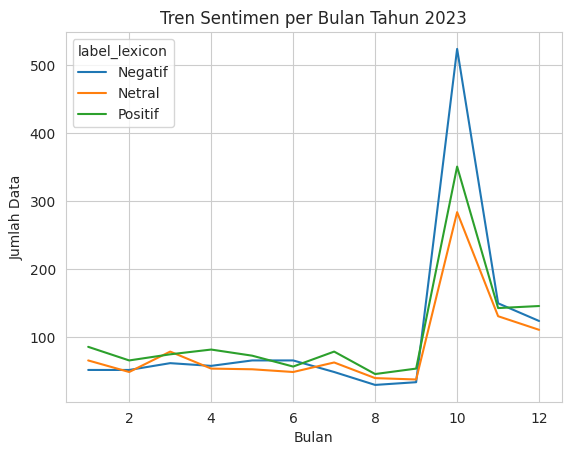

In [ ]:
# Filter tahun tertentu
df_2023 = df[df['at'].dt.year == 2023]

df_2023['month'] = df_2023['at'].dt.month

monthly_2023 = df_2023.groupby(['month', 'label_lexicon']).size().unstack(fill_value=0)

plt.figure()
monthly_2023.plot()
plt.title("Tren Sentimen per Bulan Tahun 2023")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.show()

/tmp/ipython-input-1897676168.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2024['month'] = df_2024['at'].dt.month


<Figure size 640x480 with 0 Axes>

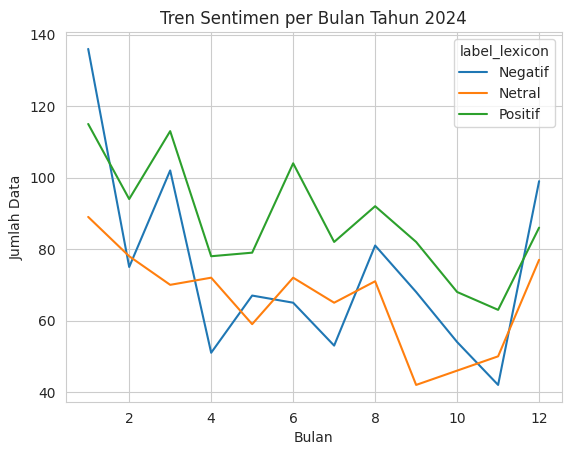

In [ ]:
# Filter tahun tertentu
df_2024 = df[df['at'].dt.year == 2024]

df_2024['month'] = df_2024['at'].dt.month

monthly_2024 = df_2024.groupby(['month', 'label_lexicon']).size().unstack(fill_value=0)

plt.figure()
monthly_2024.plot()
plt.title("Tren Sentimen per Bulan Tahun 2024")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.show()

/tmp/ipython-input-2083034692.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['month'] = df_2025['at'].dt.month


<Figure size 640x480 with 0 Axes>

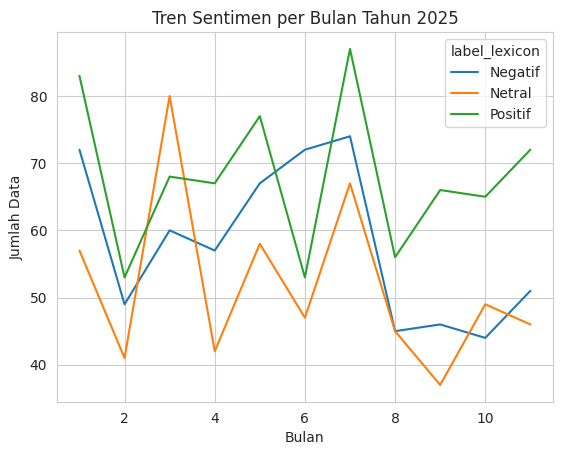

In [ ]:
# Filter tahun tertentu
df_2025 = df[df['at'].dt.year == 2025]

df_2025['month'] = df_2025['at'].dt.month

monthly_2025 = df_2025.groupby(['month', 'label_lexicon']).size().unstack(fill_value=0)

plt.figure()
monthly_2025.plot()
plt.title("Tren Sentimen per Bulan Tahun 2025")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Data")
plt.show()

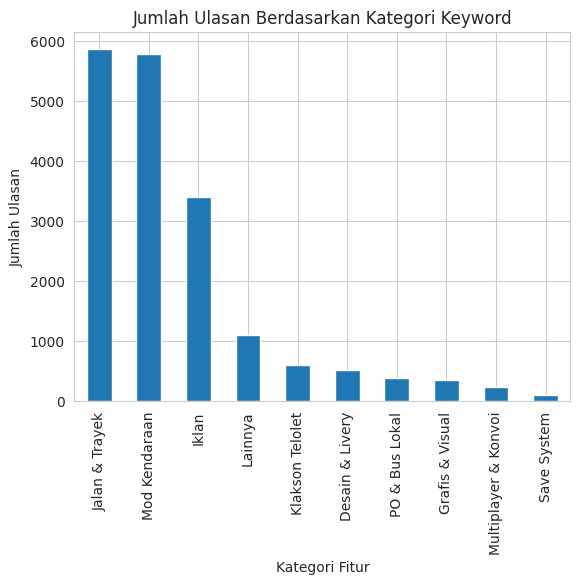

<Figure size 640x480 with 0 Axes>

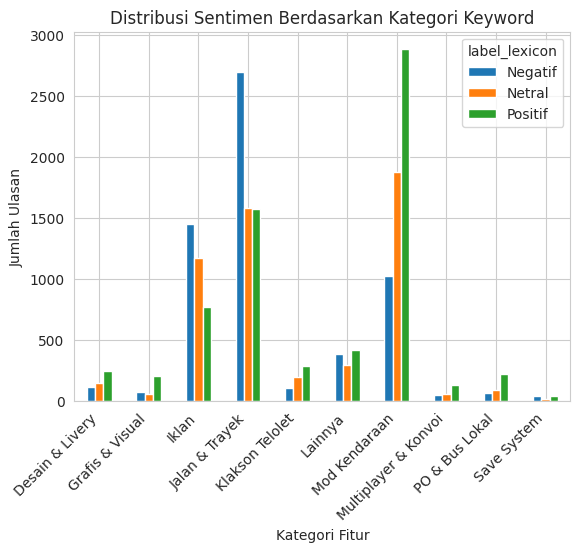

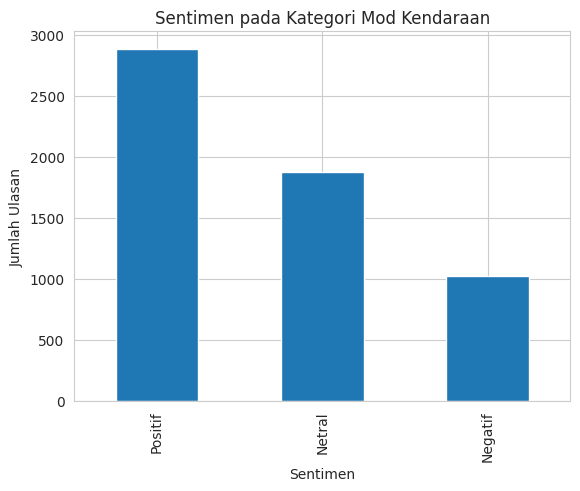

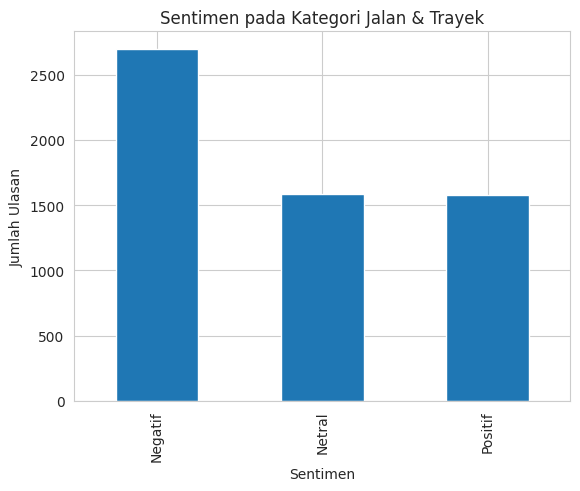

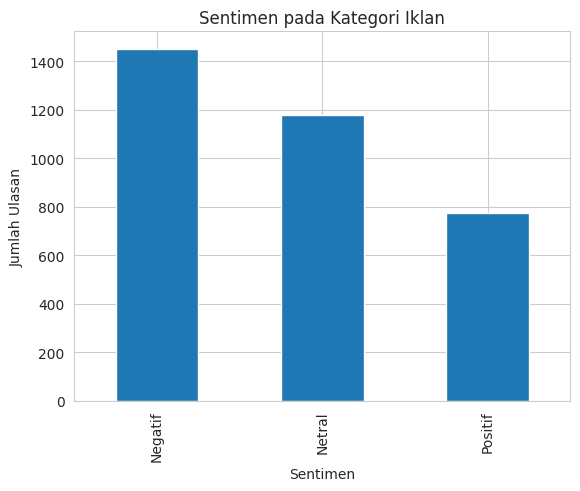

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Keyword categories
keyword_map = {
    "Desain & Livery": ['livery', 'desain', 'cat bus', 'warna bus'],
    "Jalan & Trayek": ['jalanan', 'trayek', 'rute', 'jalur', 'kota', 'desa'],
    "PO & Bus Lokal": ['po bus', 'bus asli', 'bus indonesia', 'kendaraan', 'sasis', 'mesin'],
    "Grafis & Visual": ['grafis', 'visual', 'tampilan', 'detail'],
    "Multiplayer & Konvoi": ['konvoi', 'multiplayer', 'online'],
    "Klakson Telolet": ['telolet', 'klakson'],
    "Mod Kendaraan": ['mod', 'modifikasi'],
    "Save System": ['penyimpanan', 'save', 'otomatis'],
    "Iklan": ['iklan', 'banner', 'tanpa iklan']
}

# Function to detect category
def detect_category(text):
    text = str(text).lower()
    for category, keywords in keyword_map.items():
        for kw in keywords:
            if kw in text:
                return category
    return "Lainnya"

# Apply category
df['kategori_keyword'] = df['normalisasiBaru'].apply(detect_category)

# Grafik 1: Jumlah ulasan per kategori keyword
keyword_counts = df['kategori_keyword'].value_counts()

plt.figure()
keyword_counts.plot(kind='bar')
plt.title("Jumlah Ulasan Berdasarkan Kategori Keyword")
plt.xlabel("Kategori Fitur")
plt.ylabel("Jumlah Ulasan")
plt.show()

# Grafik 2: Distribusi sentimen per kategori keyword
def detect_category(text):
    text = str(text).lower()
    for category, keywords in keyword_map.items():
        for kw in keywords:
            if kw in text:
                return category
    return "Lainnya"

df['kategori_keyword'] = df['normalisasiBaru'].apply(detect_category)

# Prepare data
sentiment_keyword = (
    df.groupby(['kategori_keyword', 'label_lexicon'])
      .size()
      .unstack(fill_value=0)
)

# Grouped bar chart (lebih mudah dibaca)
plt.figure()
sentiment_keyword.plot(kind='bar')
plt.title("Distribusi Sentimen Berdasarkan Kategori Keyword")
plt.xlabel("Kategori Fitur")
plt.ylabel("Jumlah Ulasan")
plt.xticks(rotation=45, ha='right')
plt.show()

# Grafik 3: Fokus kategori tertentu ( Mod Kendaraan)
# Filter kategori Mod Kendaraan
mod_df = df[df['kategori_keyword'] == 'Mod Kendaraan']

# Hitung jumlah sentimen
sentimen_mod = mod_df['label_lexicon'].value_counts()

# Buat grafik
plt.figure()
sentimen_mod.plot(kind='bar')
plt.title("Sentimen pada Kategori Mod Kendaraan")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()


jalan_trayek = df[df['kategori_keyword'] == "Jalan & Trayek"]
jalan_sentiment = jalan_trayek['label_lexicon'].value_counts()

plt.figure()
jalan_sentiment.plot(kind='bar')
plt.title("Sentimen pada Kategori Jalan & Trayek")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()

# Filter kategori Iklan
iklan_df = df[df['kategori_keyword'] == 'Iklan']

# Hitung jumlah sentimen
sentimen_iklan = iklan_df['label_lexicon'].value_counts()

# Buat grafik
plt.figure()
sentimen_iklan.plot(kind='bar')
plt.title("Sentimen pada Kategori Iklan")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.show()



